# Exploratory Data Analysis

This notebook keeps EDA focused and concise:
- quick data health checks,
- essential visualizations,
- a correlation view.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/processed/cleaned_data.csv"
IMPUTED_RATE_VALUE = 3.700448817952718

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Imputed-rate rows:", (df["rate"] == IMPUTED_RATE_VALUE).sum())

df.head()

Shape: (51717, 11)
Imputed-rate rows: 10052


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_costfor_two_people,listed_intype,listed_incity
0,Jalsa,1,1,4.1,775,Banashankari,Casual Dining,North Indian,800.0,Buffet,Banashankari
1,Spice Elephant,1,0,4.1,787,Banashankari,Casual Dining,Chinese,800.0,Buffet,Banashankari
2,San Churro Cafe,1,0,3.8,918,Banashankari,Cafe,Cafe,800.0,Buffet,Banashankari
3,Addhuri Udupi Bhojana,0,0,3.7,88,Banashankari,Quick Bites,South Indian,300.0,Buffet,Banashankari
4,Grand Village,0,0,3.8,166,Basavanagudi,Casual Dining,North Indian,600.0,Buffet,Banashankari


## 1) Quick Data Health

In [3]:
summary = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "missing_values": [int(df.isna().sum().sum())],
        "duplicates": [int(df.duplicated().sum())],
    }
)

summary

,rows,columns,missing_values,duplicates
0,51717,11,0,108


## 2) Core Visuals and Correlation

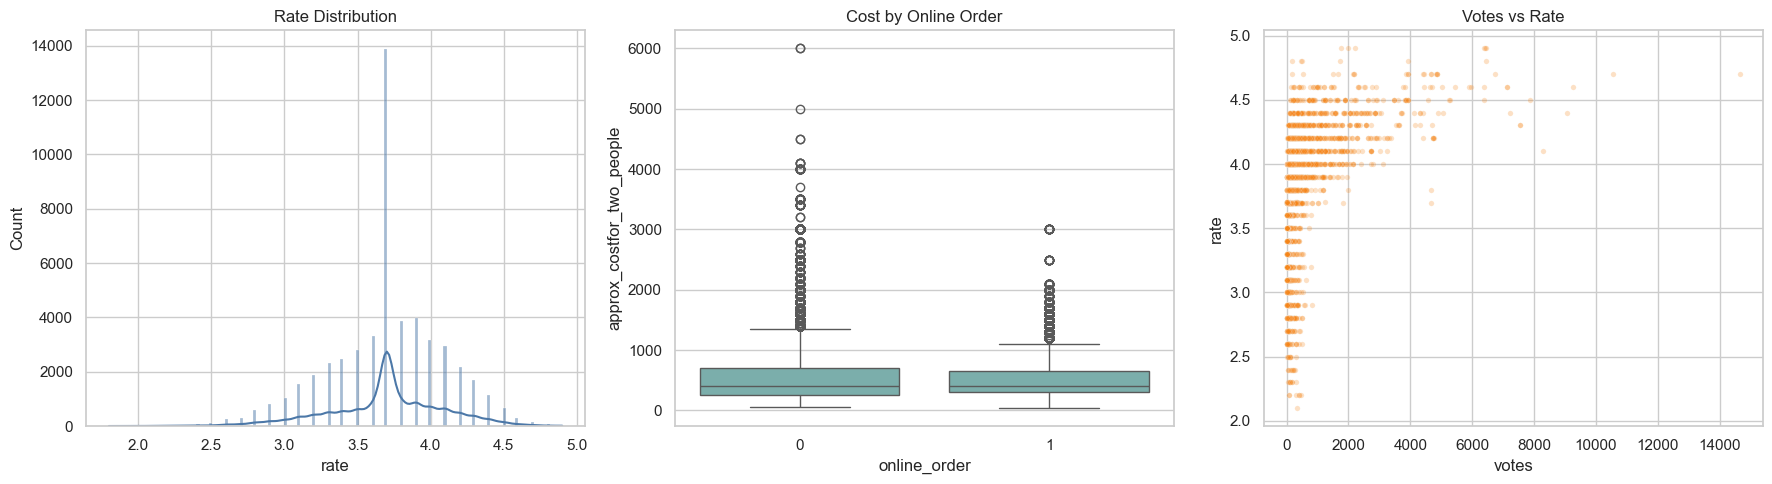

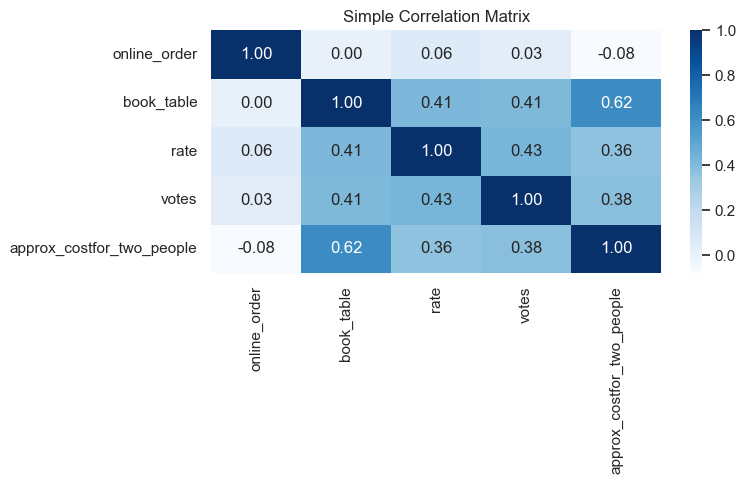

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["rate"], kde=True, ax=axes[0], color="#4c78a8")
axes[0].set_title("Rate Distribution")

sns.boxplot(data=df, x="online_order", y="approx_costfor_two_people", ax=axes[1], color="#72b7b2")
axes[1].set_title("Cost by Online Order")

sample_df = df.sample(min(6000, len(df)), random_state=42)
sns.scatterplot(data=sample_df, x="votes", y="rate", alpha=0.25, s=15, ax=axes[2], color="#f58518")
axes[2].set_title("Votes vs Rate")

plt.tight_layout()
plt.show()

corr_cols = ["online_order", "book_table", "rate", "votes", "approx_costfor_two_people"]
plt.figure(figsize=(8, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="Blues")
plt.title("Simple Correlation Matrix")
plt.tight_layout()
plt.show()